## Imports

In [1]:
import os                    
import matplotlib           
import matplotlib.pyplot as plt
import numpy as np            
import astropy.io.fits       
import astropy.coordinates   
import fitsio               
import sdss_access          
from astropy.coordinates import SkyCoord
import astropy.units as u

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

## Allspec

In [2]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('', full=allspec_file):
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()

allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

## Unique objects

In [3]:
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

## Fries's Quasar

In [4]:
# Fries's quasar coordinates
ra_fries = 212.67189
dec_fries = 53.313609

target = SkyCoord(ra_fries*u.deg, dec_fries*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
fries_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Fries's SDSS-V ID:", fries_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)

Fries's SDSS-V ID: 62243506
Angular separation (arcsec): [0.23233907]


In [5]:
# check how mny visits this quasar has (hopefully a lot)
fries_rows = allspec[allspec['sdss_id'] == fries_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(fries_rows))

Number of epochs: 280


The Spectra

In [81]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra = []

for row in fries_rows:
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })

## Loading spAll

In [82]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall = fitsio.read(spall_file, columns=spall_columns)
spall_rows_fries = spall[spall['SDSS_ID'] == fries_sdss_id]
print(spall_rows_fries['Z'])
z_fries = np.nanmedian(spall_rows_fries['Z'])
print("Fries median redshift:", z_fries)

spAll file: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz
[0.3618605  0.36197636 0.3617574  0.3620082  0.36171433 0.36175856
 0.36173508 0.36170194 0.36175203 0.3621138  0.3619729  0.36186185
 0.36186624 0.36183053 0.36179656 0.3617485  0.36179873 0.36188015
 0.36211374 0.3618566  0.36218318 0.36214086 0.36199072 0.3621246
 0.36208212 0.36195245 0.36194625 0.36208022 0.36207116 0.3620692
 0.36185    0.36214396 0.36211532 0.36206537 0.3620477  0.6701438
 0.36195973 0.36213586 0.3621647  0.36201563 0.36204848 0.3618897
 0.3618902  0.3618361  0.362116   0.36192483 0.3619615  0.3619282
 0.3618892  0.36209273 0.36192626 0.36196038 0.3619643  0.3623556
 0.36242092 0.3620125  0.3625006  0.3621733  0.36256585 0.36251634
 0.36250922 0.3620076  0.3620246  0.3618212  0.36205733 0.36185077
 0.36175546 0.36176348 0.36158508 0.3615575  0.36175618 0.36156446
 0.36190262 0.36165494 0.36166543 0.36154643 0.36167973 0.3614836
 0.36162034 0.36241087 0.36236888 0.36232

## Rest Wavelengths and Observed Wavelengths

In [94]:
## useful atomic emission lines in quasar spectra (units of Angstrom, same as our spectra): ##
    # (from day 1 nb)
rest_lambda = {
    "OVI":     1034.0,
    "Lyalpha": 1216.0,
    "CIV":     1549.0,
    "CIII":    1908.0,
    "MGII":    2799.0,
    "Hbeta":   4862.0,
    "Hgamma":  4361.0,
    "Halpha":  6564.0,
    "Oiii": 5007.0
}

# H Beta
lambda_rest_h_beta = rest_lambda["Hbeta"]
# H alpha
lambda_rest_h_alpha = rest_lambda["Halpha"]
# Oiii
lambda_rest_oiii = rest_lambda["Oiii"]

# Centers
center_hb_fries = lambda_rest_h_beta * (1+z_fries)
center_ha_fries = lambda_rest_h_alpha * (1+z_fries)
center_oiii_fries = lambda_rest_oiii * (1+z_fries)

print(f'Fries Hβ observed center: {center_hb_fries:.2f} Å')
print(f'Fries Hα observed center: {center_ha_fries:.2f} Å')
print(f'Fries Oiii observed center: {center_oiii_fries:.2f} Å')

Fries Hβ observed center: 6621.85 Å
Fries Hα observed center: 8939.91 Å
Fries Oiii observed center: 6819.34 Å


## Useful Functions

In [95]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

In [96]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

## Hβ Fries

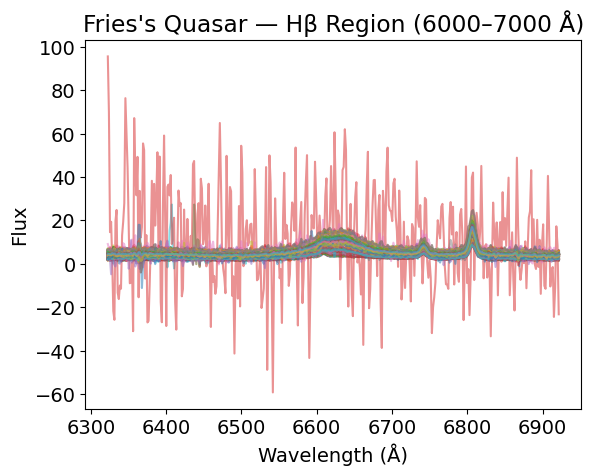

In [97]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_fries - 300) & (wl < center_hb_fries + 300)
    plt.plot(wl[mask_beta], fl[mask_beta], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hβ Region (6000–7000 Å)")
plt.show();

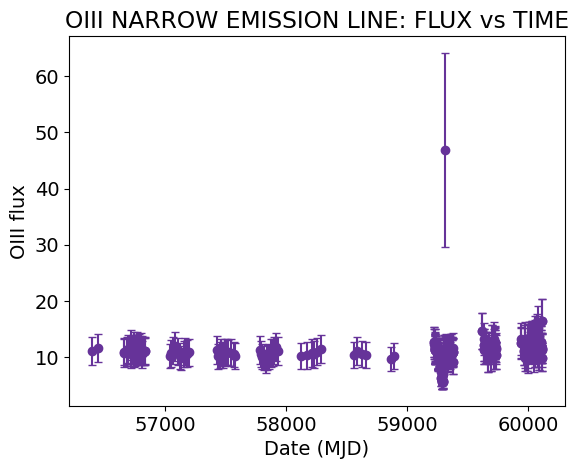

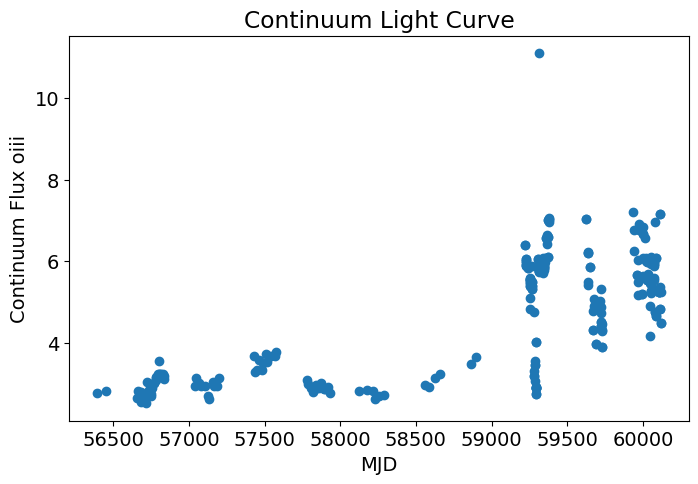

In [98]:
### Check Oiii Lab3 techniques

oiii_flux_fries = []
oiii_err_fries = []
oiii_mjd_fries = []

# window of +/- 50? like in lab03
window = 50

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl-center_oiii_fries))
    flux_zoom = fl[i-window : i+window]
    oiii_peak = np.argmax(flux_zoom)
    oiii_peak_flux = flux_zoom[oiii_peak]
    oiii_background=np.median(np.append(flux_zoom[:5],flux_zoom[-5:]))
    oiii_flux = oiii_peak_flux - oiii_background
    oiii_err = np.std(flux_zoom)
    #append
    oiii_flux_fries.append(oiii_flux)
    oiii_err_fries.append(oiii_err)
    oiii_mjd_fries.append(mjd)
    
plt.errorbar(oiii_mjd_fries,oiii_flux_fries, yerr=oiii_err_fries, linestyle='', marker='o', capsize=3, color='rebeccapurple')
plt.title('OIII NARROW EMISSION LINE: FLUX vs TIME')
plt.xlabel('Date (MJD)')
plt.ylabel('OIII flux')
plt.show();

cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl-center_oiii_fries))
    flux_zoom = fl[i-window : i+window]
    oiii_peak = np.argmax(flux_zoom)
    oiii_peak_flux = flux_zoom[oiii_peak]
    oiii_background=np.median(np.append(flux_zoom[:5],flux_zoom[-5:]))
    oiii_flux = oiii_peak_flux - oiii_background
    oiii_err = np.std(flux_zoom)
    #append
    oiii_flux_fries.append(oiii_flux)
    oiii_err_fries.append(oiii_err)
    oiii_mjd_fries.append(mjd)
    f = continuum_flux(wl, fl, center_oiii_fries - 250, center_oiii_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux oiii")
plt.title("Continuum Light Curve")
plt.show();

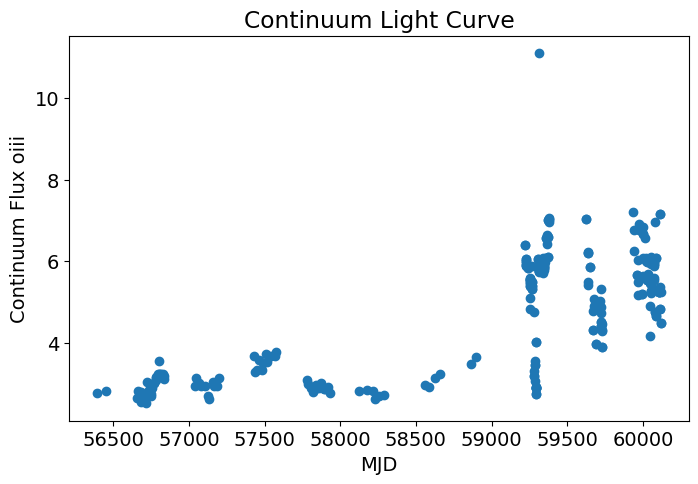

In [99]:
cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_oiii_fries - 250, center_oiii_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux oiii")
plt.title("Continuum Light Curve")
plt.show();

In [100]:
max(spectra[-200]["flux"])

8472587.0

In [72]:
# Normalized plot
hb_norm = []
hb_wl = []
hb_mjd = []

# random numbers?
window = 150
edge = 30

for s in spectra: ### -201 is the crazy blue one, -167 gets rid of crazy red one
    for i in spectra[s]["flux"]:
        if i > 20:
            pass
        else:
        

            wl = s["wavelength"]
            fl = s["flux"]
            mjd = s["mjd"]

            i = np.argmin(abs(wl -center_hb_fries))
            wl_zoom   = wl[i-window : i+window]
            fl_zoom   = fl[i-window : i+window]
            cont = np.median(np.append(fl_zoom[:edge], fl_zoom[-edge:]))
            #subtract cont - flux
            fl_diff = fl_zoom - cont 
            #append
            hb_norm.append(fl_diff)
            hb_wl.append(wl_zoom)
            hb_mjd.append(mjd)

# plot
plt.figure(figsize=(8,5))
for wl_zoom, fl_diff in zip(hb_wl, hb_norm):
    plt.plot(wl_zoom, fl_diff)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ Profiles")
plt.show();

print(f'Fries Hβ observed center: {center_hb_fries:.2f} Å')
print(f'Fries Hα observed center: {center_ha_fries:.2f} Å')
print(f'Fries Oiii observed center: {center_oiii_fries:.2f} Å')
#print("YIKES!!!")

[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_882/1088879482.py", line 11, in <module>
    for i in spectra[s]["flux"]:
TypeError: list indices must be integers or slices, not dict



In [105]:
# Normalized plot
hb_norm = []
hb_wl = []
hb_mjd = []

# random numbers?
window = 150
edge = 30
#spectra.pop(-200)
i = -1

for s in spectra: ### -201 is the crazy blue one, -167 gets rid of crazy red one
    i += 1
    if i == spectra.len() -:
        continue
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl -center_hb_fries))
    wl_zoom   = wl[i-window : i+window]
    fl_zoom   = fl[i-window : i+window]
    cont = np.median(np.append(fl_zoom[:edge], fl_zoom[-edge:]))
    #subtract cont - flux
    fl_diff = fl_zoom - cont 
    #append
    hb_norm.append(fl_diff)
    hb_wl.append(wl_zoom)
    hb_mjd.append(mjd)
    

# plot
plt.figure(figsize=(8,5))
for wl_zoom, fl_diff in zip(hb_wl, hb_norm):
    plt.plot(wl_zoom, fl_diff)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ Profiles")
plt.show();

print(f'Fries Hβ observed center: {center_hb_fries:.2f} Å')
print(f'Fries Hα observed center: {center_ha_fries:.2f} Å')
print(f'Fries Oiii observed center: {center_oiii_fries:.2f} Å')
#print("YIKES!!!")

[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_882/2236012757.py", line 12, in <module>
    if s == spectra[-200]:
ValueError: operands could not be broadcast together with shapes (4612,) (4648,)



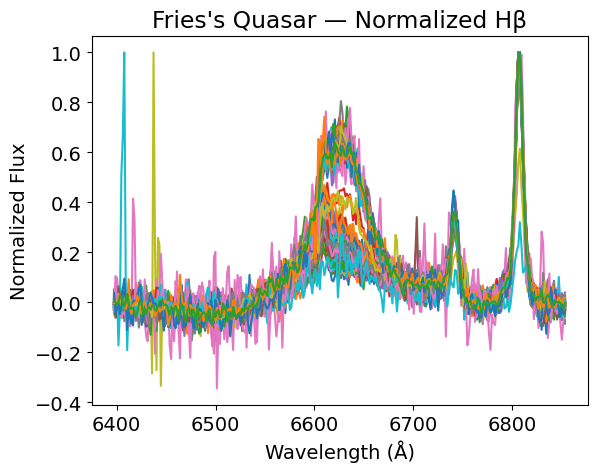

In [102]:
hb_norm = []
hb_wl = []
hb_mjd = []

window = 150   # narrower region
edge   = 30    # continuum from edges

for s in spectra[:-167]:
    wl  = s["wavelength"]
    fl  = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl - center_hb_fries))
    
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    cont = np.median(np.append(fl_zoom[:edge], fl_zoom[-edge:]))
    fl_line = fl_zoom - cont
    peak = np.max(fl_line)
    fl_norm = fl_line / peak
    
    hb_norm.append(fl_norm)
    hb_wl.append(wl_zoom)
    hb_mjd.append(mjd)

for wl_zoom, fl_norm in zip(hb_wl, hb_norm):
    plt.plot(wl_zoom, fl_norm)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ")
plt.show();
#print("Double YIKES!!!")

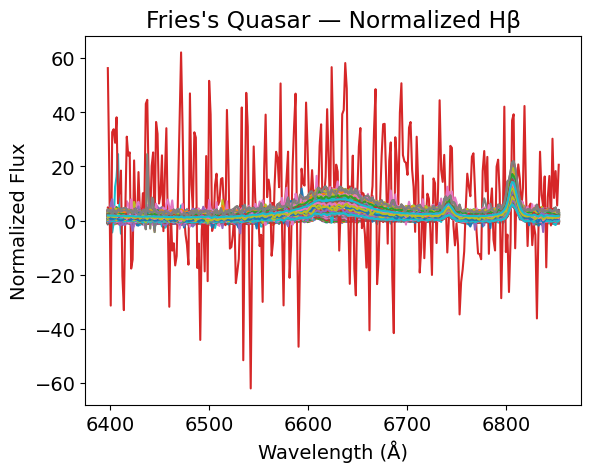

In [103]:
### Try fitting a Gaussian to Broad Hbeta then subtract the model from the data 
# Equation: F_residual (lambda) = F(lambda) - F_broad model(lambda)
## Guassian model function from day 2 notebook (nb) ##
window = 150

from scipy.optimize import curve_fit
def gaussian(x, *p):
    A, mu, sigma, B = p
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))+B

# try with one epoch first
epoch = spectra[0]

wl= epoch["wavelength"]
fl = epoch["flux"]
i = np.argmin(abs(wl - center_hb_fries))  
wl_zoom = wl[i-window : i+window]
fl_zoom = fl[i-window : i+window]

#Guess
A_guess = fl_zoom.max() - np.median(fl_zoom) # maximum value of Gaussian above a flat line
mu_guess = center_hb_fries # center of Gaussian function
sigma_guess = 20 # stdev?
B_guess = np.median(fl_zoom) # constant level
p_guess = [A_guess,mu_guess,sigma_guess,B_guess]
#fit
fit, cov = curve_fit(gaussian, wl_zoom, fl_zoom, p0=p_guess)
A_fit, mu_fit, sigma_fit, B_fit = fit
model = gaussian(wl_zoom, *fit)

### Now subtract model from data
hb_res = []
hb_res_wl = []
hb_res_mjd = []

for s in spectra:
    wl= s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]
    i = np.argmin(abs(wl - center_hb_fries))  
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    #sub
    fl_res = fl_zoom - gaussian(wl_zoom, *fit)
    
    hb_res.append(fl_res)
    hb_res_wl.append(wl_zoom)
    hb_res_mjd.append(mjd)
    
### PLot
for wl_zoom, fl_res in zip(hb_res_wl, hb_res):
    plt.plot(wl_zoom, fl_res)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ")
plt.show();

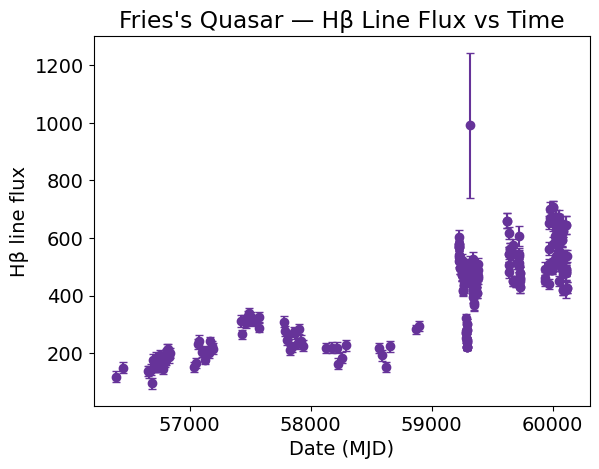

In [16]:
hb_flux_fries = []
hb_err_fries  = []
hb_mjd_fries  = []

window = 80    # narrower than before, focused on Hβ
edge   = 20

for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]
    mjd = s["mjd"]
    
    # index near Hβ
    i = np.argmin(abs(wl - center_hb_fries))
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    
    # continuum from edges
    cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
    cont = np.median(cont_vals)
    
    # continuum-subtracted line
    fl_line = fl_zoom - cont
    
    # approximate line flux = integral
    line_flux = np.trapz(fl_line, wl_zoom)
    
    # crude error estimate from scatter in continuum
    noise = np.std(cont_vals)
    line_err = noise * (wl_zoom.max() - wl_zoom.min())**0.5  # rough
    
    hb_flux_fries.append(line_flux)
    hb_err_fries.append(line_err)
    hb_mjd_fries.append(mjd)

plt.errorbar(hb_mjd_fries, hb_flux_fries, yerr=hb_err_fries,
             linestyle='', marker='o', capsize=3, color='rebeccapurple')
plt.xlabel("Date (MJD)")
plt.ylabel("Hβ line flux")
plt.title("Fries's Quasar — Hβ Line Flux vs Time")
plt.show();


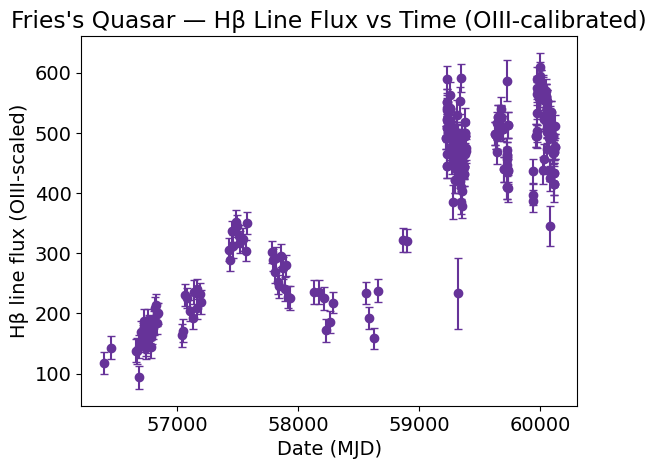

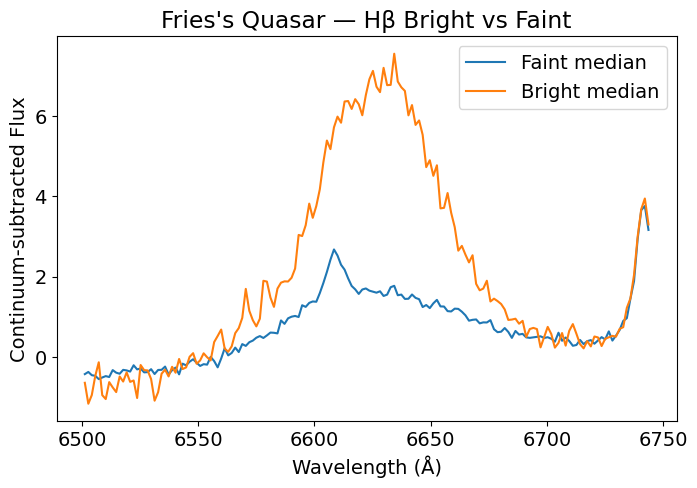

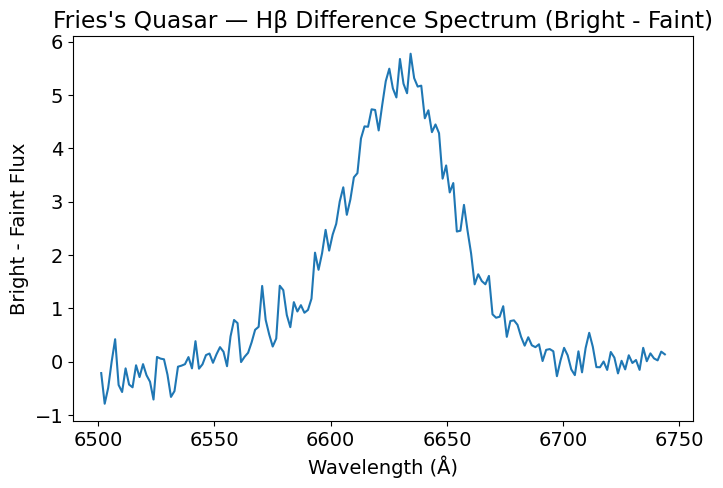

In [17]:
#### Okay maybe I will try to uuse Oiii as a ??????????????
oiii_flux = np.array(oiii_flux_fries)
scale_ref = np.median(oiii_flux)          # target OIII flux
scale_factors = scale_ref / oiii_flux     # multiply each spectrum by this

hb_flux_fries = []
hb_err_fries  = []
hb_mjd_fries  = []

window = 80
edge   = 20

for s, scale in zip(spectra, scale_factors):
    wl  = s["wavelength"]
    fl  = s["flux"] * scale      # <-- OIII-calibrated flux
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl - center_hb_fries))
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    
    cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
    cont = np.median(cont_vals)
    
    fl_line = fl_zoom - cont
    line_flux = np.trapz(fl_line, wl_zoom)
    
    noise = np.std(cont_vals)
    line_err = noise * (wl_zoom.max() - wl_zoom.min())**0.5
    
    hb_flux_fries.append(line_flux)
    hb_err_fries.append(line_err)
    hb_mjd_fries.append(mjd)

plt.errorbar(hb_mjd_fries, hb_flux_fries, yerr=hb_err_fries,
             linestyle='', marker='o', capsize=3, color='rebeccapurple')
plt.xlabel("Date (MJD)")
plt.ylabel("Hβ line flux (OIII-scaled)")
plt.title("Fries's Quasar — Hβ Line Flux vs Time (OIII-calibrated)")
plt.show();

cont_levels = []

window = 80
edge   = 20

for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]
    
    i = np.argmin(abs(wl - center_hb_fries))
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    
    cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
    cont = np.median(cont_vals)
    cont_levels.append(cont)

cont_levels = np.array(cont_levels)
order = np.argsort(cont_levels)

n = 10   # number of bright/faint epochs to use
faint_idx = order[:n]
bright_idx = order[-n:]


hb_profiles = []
hb_wl = []

for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]
    
    i = np.argmin(abs(wl - center_hb_fries))
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    
    cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
    cont = np.median(cont_vals)
    
    fl_line = fl_zoom - cont
    hb_profiles.append(fl_line)
    hb_wl.append(wl_zoom)

hb_profiles = np.array(hb_profiles)
wl_ref = hb_wl[0]

bright_med = np.median(hb_profiles[bright_idx], axis=0)
faint_med  = np.median(hb_profiles[faint_idx], axis=0)
diff = bright_med - faint_med

plt.figure(figsize=(8,5))
plt.plot(wl_ref, faint_med,  label='Faint median')
plt.plot(wl_ref, bright_med, label='Bright median')
plt.xlabel("Wavelength (Å)")
plt.ylabel("Continuum-subtracted Flux")
plt.title("Fries's Quasar — Hβ Bright vs Faint")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(wl_ref, diff)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Bright - Faint Flux")
plt.title("Fries's Quasar — Hβ Difference Spectrum (Bright - Faint)")
plt.show();


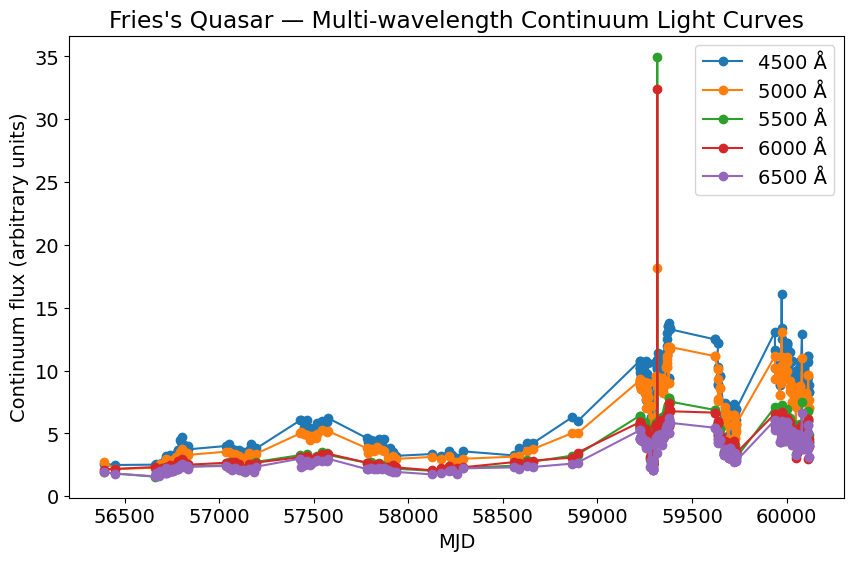

In [18]:
#### Not working so let's try to recreate something like the luminosity mjd plot from class

cont_wavelengths = [4500, 5000, 5500, 6000, 6500]
window = 5   # Å on each side

cont_lightcurves = {lam: [] for lam in cont_wavelengths}
mjds = []

for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]
    mjd = s["mjd"]
    
    mjds.append(mjd)
    
    for lam in cont_wavelengths:
        i = np.argmin(abs(wl - lam))
        wl_zoom = wl[i-window : i+window]
        fl_zoom = fl[i-window : i+window]
        
        cont_flux = np.median(fl_zoom)
        cont_lightcurves[lam].append(cont_flux)
mjds = np.array(mjds)

order = np.argsort(mjds)
mjds_sorted = mjds[order]

plt.figure(figsize=(10,6))
for lam, fluxes in cont_lightcurves.items():
    fluxes = np.array(fluxes)[order]          # sort to match MJD
    plt.plot(mjds_sorted, fluxes, marker='o', linestyle='-', label=f"{lam} Å")

plt.xlabel("MJD")
plt.ylabel("Continuum flux (arbitrary units)")
plt.title("Fries's Quasar — Multi-wavelength Continuum Light Curves")
plt.legend()
plt.show();


[WARNING]: Mean of empty slice. (RuntimeWarning)
[WARNING]: invalid value encountered in divide (RuntimeWarning)


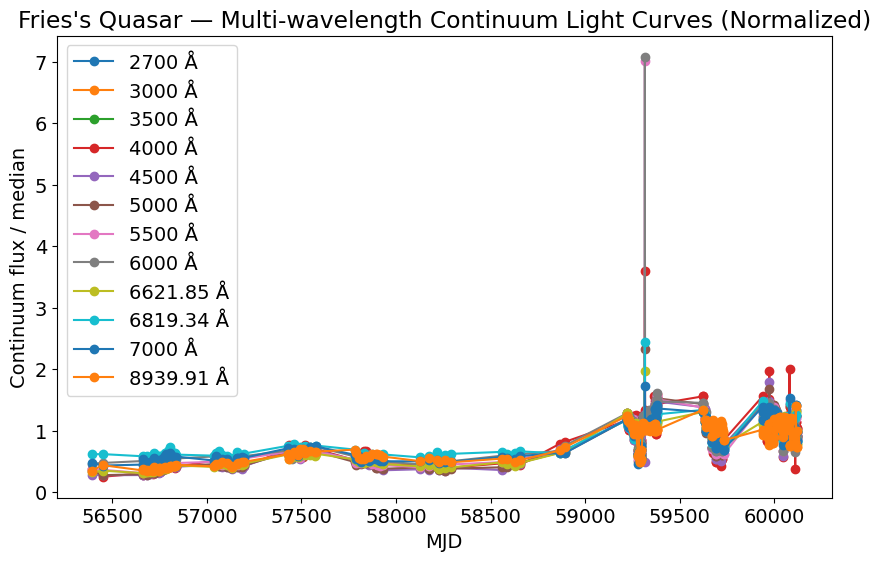

In [19]:
### Multi-wavelength continuum light curves (Fries-style)
# We measure continuum flux at several wavelengths, sort by MJD,
# and normalize each curve by its median so shapes can be compared.


#Fries Hβ observed center: 6621.85 Å
#Fries Hα observed center: 8939.91 Å
#Fries Oiii observed center: 6819.34 Å
cont_wavelengths = [2700, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6621.85, 6819.34, 7000, 8939.91] 
window = 5   # +/- 5 Å around each wavelength

cont_lightcurves = {lam: [] for lam in cont_wavelengths}
mjds = []

# --- Extract continuum fluxes ---
for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]
    mjd = s["mjd"]
    
    mjds.append(mjd)
    
    for lam in cont_wavelengths:
        i = np.argmin(abs(wl - lam))
        wl_zoom = wl[i-window : i+window]
        fl_zoom = fl[i-window : i+window]
        
        cont_flux = np.median(fl_zoom)
        cont_lightcurves[lam].append(cont_flux)

# --- Sort by MJD ---
mjds = np.array(mjds)
order = np.argsort(mjds)
mjds_sorted = mjds[order]

# --- Plot ---
plt.figure(figsize=(10,6))

for lam in cont_wavelengths:
    fluxes = np.array(cont_lightcurves[lam])[order]   # sort fluxes to match MJD
    fluxes_norm = fluxes / np.median(fluxes)          # normalize by median
    
    plt.plot(mjds_sorted, fluxes_norm, marker='o', linestyle='-', label=f"{lam} Å")

plt.xlabel("MJD")
plt.ylabel("Continuum flux / median")
plt.title("Fries's Quasar — Multi-wavelength Continuum Light Curves (Normalized)")
plt.legend()
plt.show();



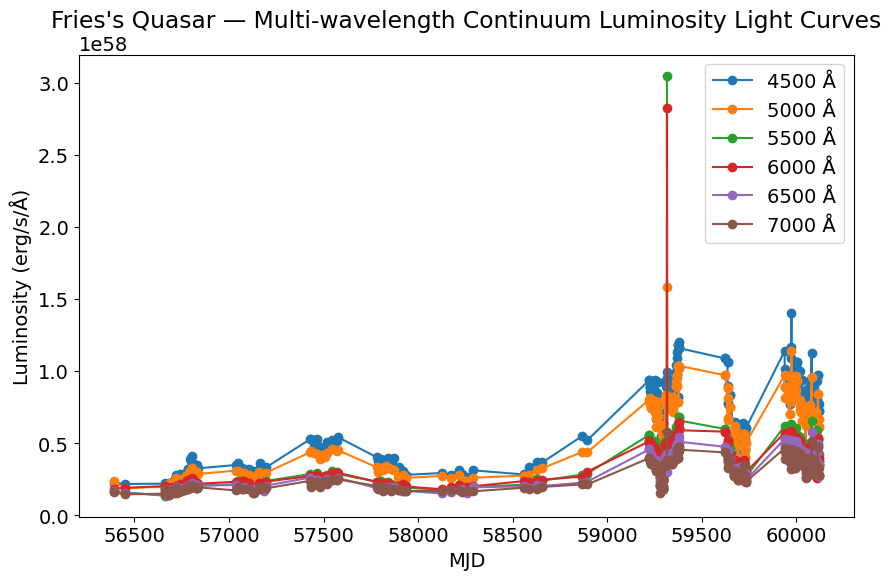

In [20]:
### Multi-wavelength continuum luminosity light curves (Fries-style)

import numpy as np
import matplotlib.pyplot as plt

# --- Continuum wavelengths (line-free) ---
cont_wavelengths = [4500, 5000, 5500, 6000, 6500, 7000]
window = 5   # +/- 5 Å around each wavelength

# --- Luminosity distance for Fries's quasar (z ~ 0.47) ---
# D_L ≈ 2.7 Gpc
D_L_pc = 2.7e9                     # parsecs
D_L_cm = D_L_pc * 3.086e18         # convert to cm

# --- Storage ---
cont_lightcurves = {lam: [] for lam in cont_wavelengths}
mjds = []

# --- Extract continuum fluxes ---
for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]                 # flux in erg/s/cm^2/Å
    mjd = s["mjd"]
    
    mjds.append(mjd)
    
    for lam in cont_wavelengths:
        i = np.argmin(abs(wl - lam))
        wl_zoom = wl[i-window : i+window]
        fl_zoom = fl[i-window : i+window]
        
        cont_flux = np.median(fl_zoom)   # erg/s/cm^2/Å
        cont_lightcurves[lam].append(cont_flux)

# --- Sort by MJD ---
mjds = np.array(mjds)
order = np.argsort(mjds)
mjds_sorted = mjds[order]

# --- Plot luminosity ---
plt.figure(figsize=(10,6))

for lam in cont_wavelengths:
    fluxes = np.array(cont_lightcurves[lam])[order]   # sorted fluxes
    
    # Convert to luminosity: L = 4π D_L^2 F
    luminosities = 4 * np.pi * (D_L_cm**2) * fluxes   # erg/s/Å
    
    plt.plot(mjds_sorted, luminosities, marker='o', linestyle='-', label=f"{lam} Å")

plt.xlabel("MJD")
plt.ylabel("Luminosity (erg/s/Å)")
plt.title("Fries's Quasar — Multi-wavelength Continuum Luminosity Light Curves")
plt.legend()
plt.show()


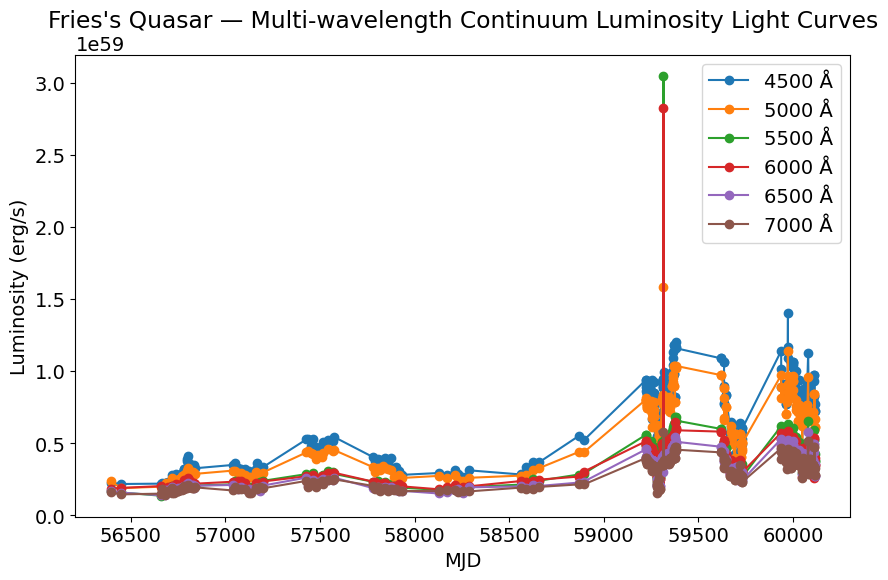

In [21]:
### Multi-wavelength continuum luminosity light curves (Fries-style, erg/s)

import numpy as np
import matplotlib.pyplot as plt

# --- Continuum wavelengths (line-free) ---
cont_wavelengths = [4500, 5000, 5500, 6000, 6500, 7000]
window = 5   # +/- 5 Å around each wavelength
delta_lambda = 2 * window   # integration width = 10 Å

# --- Luminosity distance for Fries's quasar (z ~ 0.47) ---
D_L_pc = 2.7e9                     # parsecs
D_L_cm = D_L_pc * 3.086e18         # convert to cm

# --- Storage ---
cont_lightcurves = {lam: [] for lam in cont_wavelengths}
mjds = []

# --- Extract continuum fluxes ---
for s in spectra:
    wl  = s["wavelength"]
    fl  = s["flux"]                 # erg/s/cm^2/Å
    mjd = s["mjd"]
    
    mjds.append(mjd)
    
    for lam in cont_wavelengths:
        i = np.argmin(abs(wl - lam))
        wl_zoom = wl[i-window : i+window]
        fl_zoom = fl[i-window : i+window]
        
        cont_flux = np.median(fl_zoom)   # erg/s/cm^2/Å
        cont_lightcurves[lam].append(cont_flux)

# --- Sort by MJD ---
mjds = np.array(mjds)
order = np.argsort(mjds)
mjds_sorted = mjds[order]

# --- Plot luminosity ---
plt.figure(figsize=(10,6))

for lam in cont_wavelengths:
    fluxes = np.array(cont_lightcurves[lam])[order]   # sorted fluxes
    
    # Convert to luminosity density: Lλ = 4π D_L^2 Fλ
    L_lambda = 4 * np.pi * (D_L_cm**2) * fluxes       # erg/s/Å
    
    # Convert to integrated luminosity: L = Lλ * Δλ
    L = L_lambda * delta_lambda                       # erg/s
    
    plt.plot(mjds_sorted, L, marker='o', linestyle='-', label=f"{lam} Å")

plt.xlabel("MJD")
plt.ylabel("Luminosity (erg/s)")
plt.title("Fries's Quasar — Multi-wavelength Continuum Luminosity Light Curves")
plt.legend()
plt.show()


In [22]:
## Hα Fries

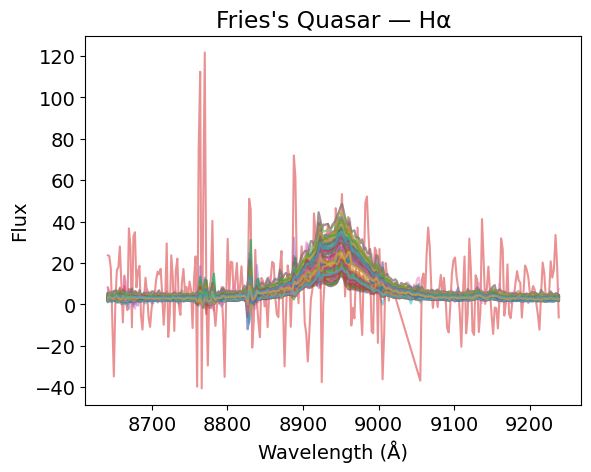

In [23]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_fries - 300) & (wl < center_ha_fries + 300)
    plt.plot(wl[mask_alpha], fl[mask_alpha], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hα")
plt.show();

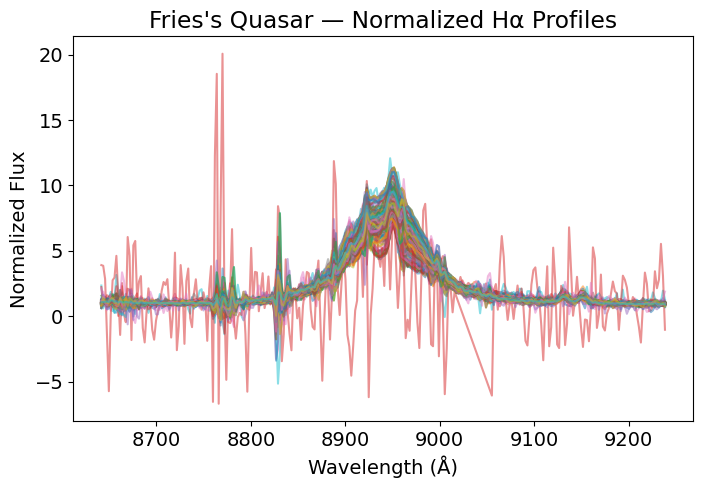

In [24]:
plt.figure(figsize=(8,5))
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_fries - 300) & (wl < center_ha_fries + 300)
    wl_zoom    = wl[mask_alpha]
    fl_zoom    = fl[mask_alpha]

    cont = continuum_flux(wl_zoom, fl_zoom,
                          center_ha_fries - 250,
                          center_ha_fries - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hα Profiles")
plt.show();

## Continuum Light Curves

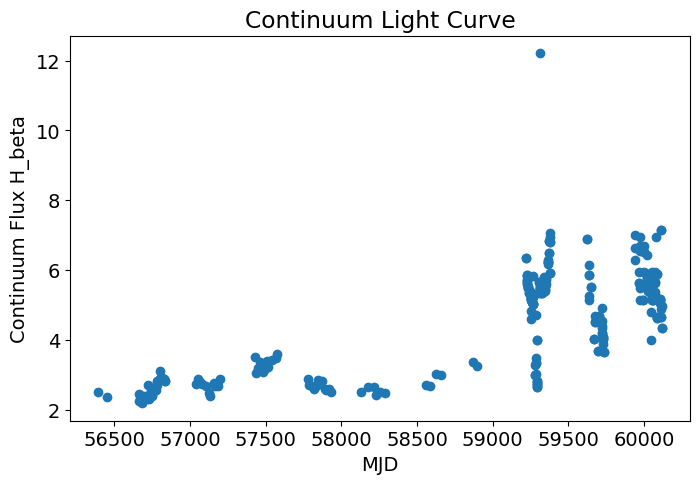

In [25]:
cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_hb_fries - 250, center_hb_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_beta")
plt.title("Continuum Light Curve")
plt.show();

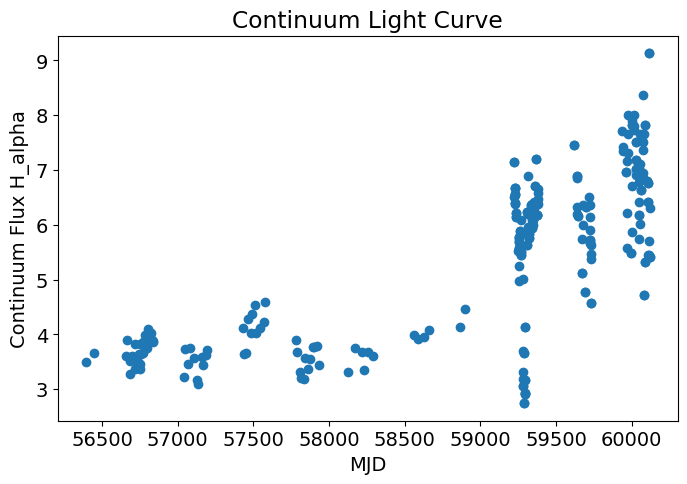

In [92]:
cont_times_fries = []
cont_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_ha_fries - 250, center_ha_fries + 150)  # from previous cells
    cont_times_fries.append(mjd)
    cont_values_fries.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_fries, cont_values_fries)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_alpha")
plt.title("Continuum Light Curve")
plt.show();

In [93]:
hb_times_fries = []
hb_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_hb_fries, width=40)
    hb_times_fries.append(mjd)
    hb_values_fries.append(f_line)
plt.scatter(hb_times_fries, hb_values_fries)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show();

[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_882/1109924476.py", line 9, in <module>
    f_line = line_flux(wl, fl, center_hb_fries, width=40)
TypeError: 'numpy.float32' object is not callable



In [91]:
ha_times_fries = []
ha_values_fries = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_ha_fries, width=40)
    ha_times_fries.append(mjd)
    ha_values_fries.append(f_line)
plt.scatter(ha_times_fries, ha_values_fries)
plt.xlabel("MJD")
plt.ylabel("Ha Line Flux")
plt.title("Ha Light Curve")
plt.show();

[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_882/169610728.py", line 9, in <module>
    f_line = line_flux(wl, fl, center_ha_fries, width=40)
TypeError: 'numpy.float32' object is not callable



In [ ]:
plt.scatter(cont_values_fries, hb_values_fries)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.ylim(0,300)
plt.title("Fries's Quasar — BLR Response to Disk Variability")
plt.show();

In [ ]:
plt.scatter(cont_values_fries, ha_values_fries)
plt.xlabel("Continuum Flux")
plt.ylabel("Ha Line Flux")
plt.title("Fries's Quasar — BLR Response to Disk Variability")
plt.ylim(0,800)
plt.show();

In [ ]:
i_bright = np.argmax(cont_values_fries)
i_faint  = np.argmin(cont_values_fries)

wl_b = spectra[i_bright]["wavelength"]
fl_b = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_b, wl_f, fl_f)

mask_diff = (wl_b > center_hb_fries - 300) & (wl_b < center_hb_fries + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask_diff], fl_b[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Fries's Quasar — Difference Spectrum (Bright - Faint) - Hb")
plt.show();

In [ ]:
i_bright = np.argmax(cont_values_fries)
i_faint  = np.argmin(cont_values_fries)

wl_a = spectra[i_bright]["wavelength"]
fl_a = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

fl_f_interp = np.interp(wl_a, wl_f, fl_f)

mask_diff = (wl_a > center_ha_fries - 300) & (wl_a < center_ha_fries + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_a[mask_diff], fl_a[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Fries's Quasar — Difference Spectrum (Bright - Faint) - Ha")
plt.show();

## Jason's Quasar

In [ ]:
# Jason's quasar coordinates
ra_jason = 213.351149549
dec_jason = 53.090819798

target = SkyCoord(ra_jason*u.deg, dec_jason*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
jason_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Jasons's SDSS-V ID:", jason_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)

In [ ]:
# check how mny visits this quasar has (hopefully a lot)
jason_rows = allspec[allspec['sdss_id'] == jason_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(jason_rows))

In [ ]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra_jason = []

for row in jason_rows:
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra_jason.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })

In [ ]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall_rows_jason = spall[spall['SDSS_ID'] == jason_sdss_id]
print(spall_rows_jason['Z'])
z_jason = np.nanmedian(spall_rows_jason['Z'])
print("Jason median redshift:", z_jason)

In [ ]:
# H Beta
lambda_rest_h_beta = rest_lambda["Hbeta"]
# H alpha
lambda_rest_h_alpha = rest_lambda["Halpha"]

# Centers
center_hb_jason = lambda_rest_h_beta * (1+z_jason)
center_ha_jason = lambda_rest_h_alpha * (1+z_jason)
center_oiii_jason = lambda_rest_oiii * (1+z_jason)

print(f'Jason Hβ observed center: {center_hb_jason:.2f} Å')
print(f'Jason Hα observed center: {center_ha_jason:.2f} Å')
print(f'Jason oiii observed center: {center_oiii_jason:.2f} Å')

In [ ]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

In [ ]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

In [ ]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_jason - 300) & (wl < center_hb_jason + 300)
    plt.plot(wl[mask_beta], fl[mask_beta], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ")
plt.show();

In [ ]:
plt.figure(figsize=(8,5))
for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_beta = (wl > center_hb_jason - 300) & (wl < center_hb_jason + 300)
    wl_zoom   = wl[mask_beta]
    fl_zoom   = fl[mask_beta]

    cont = continuum_flux(wl_zoom, fl_zoom, center_hb_jason - 250, center_hb_jason - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Jason's Quasar — Normalized Hβ")
plt.show();

In [ ]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_jason - 300) & (wl < center_ha_jason + 300)
    plt.plot(wl[mask_alpha], fl[mask_alpha], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hα")
plt.show();

In [ ]:
plt.figure(figsize=(8,5))
for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]

    mask_alpha = (wl > center_ha_jason - 300) & (wl < center_ha_jason + 300)
    wl_zoom    = wl[mask_alpha]
    fl_zoom    = fl[mask_alpha]

    cont = continuum_flux(wl_zoom, fl_zoom,center_ha_jason - 250,center_ha_jason - 150)
    plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Jason's Quasar — Normalized Hα")
plt.show();

In [ ]:
cont_times_jason = []
cont_values_jason = []

for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_hb_jason - 250, center_hb_jason + 150)
    cont_times_jason.append(mjd)
    cont_values_jason.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_jason, cont_values_jason)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_beta")
plt.title("Continuum Light Curve")
plt.show();

In [ ]:
cont_times_jason = []
cont_values_jason = []

#for s in spectra_jason[1:]:
for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_hb_jason - 250, center_hb_jason + 150)
    cont_times_jason.append(mjd)
    cont_values_jason.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_jason, cont_values_jason)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_beta")
plt.title("Continuum Light Curve")
plt.show();

In [ ]:
cont_times_jason = []
cont_values_jason = []

for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, center_ha_jason - 250, center_ha_jason + 150)
    cont_times_jason.append(mjd)
    cont_values_jason.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times_jason, cont_values_jason)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux H_alpha")
plt.title("Continuum Light Curve")
plt.show();

In [ ]:
hb_times_jason = []
hb_values_jason = []

for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_hb_jason, width=40)
    hb_times_jason.append(mjd)
    hb_values_jason.append(f_line)
plt.scatter(hb_times_jason, hb_values_jason)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show();

In [ ]:
ha_times_jason = []
ha_values_jason = []

for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f_line = line_flux(wl, fl, center_ha_jason, width=40)
    ha_times_jason.append(mjd)
    ha_values_jason.append(f_line)
plt.scatter(ha_times_jason, ha_values_jason)
plt.xlabel("MJD")
plt.ylabel("Ha Line Flux")
plt.title("Ha Light Curve")
plt.show();

In [ ]:
plt.scatter(cont_values_jason, hb_values_jason)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.title("Jason's Quasar — BLR Response to Disk Variability")
plt.show();

In [ ]:
plt.scatter(cont_values_jason, ha_values_jason)
plt.xlabel("Continuum Flux")
plt.ylabel("Ha Line Flux")
plt.title("Jason's Quasar — BLR Response to Disk Variability")
plt.show();

In [ ]:
print("Jason wl range:", wl_b.min(), wl_b.max())
print("Hb window:", center_hb_jason - 300, center_hb_jason + 300)
print("Ha window:", center_ha_jason - 300, center_ha_jason + 300)
print("N points in Hb mask:", np.sum(mask_diff))

In [ ]:
i_bright = np.argmax(cont_values_jason)
i_faint  = np.argmin(cont_values_jason)

wl_b = spectra_jason[i_bright]["wavelength"]
fl_b = spectra_jason[i_bright]["flux"]

wl_f = spectra_jason[i_faint]["wavelength"]
fl_f = spectra_jason[i_faint]["flux"]

fl_f_interp = np.interp(wl_b, wl_f, fl_f)

mask_diff = (wl_b > center_hb_jason - 300) & (wl_b < center_hb_jason + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask_diff], fl_b[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Jason's Quasar — Difference Spectrum (Bright - Faint) - Hb")
plt.show();

In [ ]:
i_bright = np.argmax(cont_values_jason)
i_faint  = np.argmin(cont_values_jason)

wl_a = spectra_jason[i_bright]["wavelength"]
fl_a = spectra_jason[i_bright]["flux"]

wl_f = spectra_jason[i_faint]["wavelength"]
fl_f = spectra_jason[i_faint]["flux"]

fl_f_interp = np.interp(wl_a, wl_f, fl_f)

mask_diff = (wl_a > center_ha_jason - 300) & (wl_a < center_ha_jason + 300)

plt.figure(figsize=(10,6))
plt.plot(wl_a[mask_diff], fl_a[mask_diff] - fl_f_interp[mask_diff])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Jason's Quasar — Difference Spectrum (Bright - Faint) - Ha")
plt.show();

In [ ]:
### Check Oiii Lab3 techniques

oiii_flux_jason = []
oiii_err_jason = []
oiii_mjd_jason = []

# window of +/- 50? like in lab03
window = 50

for s in spectra_jason:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl-center_oiii_jason))
    flux_zoom = fl[i-window : i+window]
    oiii_peak = np.argmax(flux_zoom)
    oiii_peak_flux = flux_zoom[oiii_peak]
    oiii_background=np.median(np.append(flux_zoom[:5],flux_zoom[-5:]))
    oiii_flux = oiii_peak_flux - oiii_background
    oiii_err = np.std(flux_zoom)
    #append
    oiii_flux_jason.append(oiii_flux)
    oiii_err_jason.append(oiii_err)
    oiii_mjd_jason.append(mjd)
    
plt.errorbar(oiii_mjd_jason,oiii_flux_jason, yerr=oiii_err_jason, linestyle='', marker='o', capsize=3, color='rebeccapurple')
plt.title('OIII NARROW EMISSION LINE: FLUX vs TIME')
plt.xlabel('Date (MJD)')
plt.ylabel('OIII flux')
plt.show();

In [ ]:
### Normalized Hβ profiles for Jason's Quasar

hb_norm = []
hb_wl = []
hb_mjd = []

window = 100
edge = 30

for s in spectra_jason: 
    wl  = s["wavelength"]
    fl  = s["flux"]
    mjd = s["mjd"]
    
    i = np.argmin(abs(wl - center_hb_jason))
    wl_zoom = wl[i-window : i+window]
    fl_zoom = fl[i-window : i+window]
    # continuum from edges
    cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
    cont = np.median(cont_vals)
    # continuum-subtracted line
    fl_line = fl_zoom - cont
    
    hb_norm.append(fl_line)
    hb_wl.append(wl_zoom)
    hb_mjd.append(mjd)

#PLots
for wl_zoom, fl_line in zip(hb_wl, hb_norm):
    plt.plot(wl_zoom, fl_line)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Continuum-subtracted Flux")
plt.title("Jason's Quasar — Normalized Hβ Profiles")
plt.show();


In [ ]:
from astropy.cosmology import Planck18 as cosmo
import numpy as np
import matplotlib.pyplot as plt

# continuum wavelengths
cont_wavelengths = [4500, 5000, 5500, 6000, 6500, 7000]
window = 5   # +/- 5 Å around each wavelength

# Correct luminosity distance for Jason
D_L_cm = cosmo.luminosity_distance(z_jason).to('cm').value
cont_lightcurves = {lam: [] for lam in cont_wavelengths}
mjds = []

# continuum fluxes 
for s in spectra_jason:
    wl  = s["wavelength"]
    fl  = s["flux"] # erg/s/cm^2/Å
    mjd = s["mjd"]
    
    mjds.append(mjd)
    
    for lam in cont_wavelengths:
        i = np.argmin(abs(wl - lam))
        fl_zoom = fl[i-window : i+window]
        cont_flux = np.median(fl_zoom)
        cont_lightcurves[lam].append(cont_flux)

# Sort by mjd 
mjds = np.array(mjds)
order = np.argsort(mjds)
mjds_sorted = mjds[order]

# Plot λLλ luminosity
plt.figure(figsize=(10,6))

for lam in cont_wavelengths:
    fluxes = np.array(cont_lightcurves[lam])[order]   # sorted fluxes
    
    # Convert to luminosity density: Lλ = 4π D_L^2 Fλ
    L_lambda = 4 * np.pi * (D_L_cm**2) * fluxes # erg/s/Å
    
    # Convert to λLλ (erg/s)
    lambda_L_lambda = lam * L_lambda
    
    plt.plot(mjds_sorted, lambda_L_lambda, marker='o', linestyle='-', label=f"{lam} Å")

plt.xlabel("MJD")
plt.ylabel(r"$\lambda L_\lambda$ (erg/s)")
plt.title("Jason's Quasar — Multi-wavelength Continuum Luminosity Light Curves (log scale)")
plt.yscale("log")
plt.legend()
plt.show()
